# EDA -- Exploratory Data Analysis 


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path

In [2]:
# ── Constants ────────────────────────────────────────────────────────────────
ROOT_DIR  = Path.cwd()
DATA_DIR  = ROOT_DIR / "data"
PLOTS_DIR = ROOT_DIR / "plots" / "eda_plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
PALETTE = "husl"

In [3]:

# ── Load data ─────────────────────────────────────────────────────────────────
transacciones = pd.read_csv(DATA_DIR / "customer_purchases_train.csv")
print(f"  transacciones: {transacciones.shape}")
print(transacciones.head())

  transacciones: (6892, 18)
   purchase_id customer_id customer_date_of_birth customer_gender  \
0            0   CUST_0094             03/05/1996          female   
1            1   CUST_0279             05/02/1974          female   
2            2   CUST_0775             09/10/1954            male   
3            3   CUST_0722             05/07/1963            male   
4            4   CUST_0741             07/08/1957          female   

  customer_signup_date    item_id                           item_title  \
0           07/02/2025  ITEM_0101  Exclusive Premium Blouse Collection   
1           03/02/2025  ITEM_0311         Casual Jeans That Stands Out   
2           01/02/2025  ITEM_0752    Stylish Blouse For Every Occasion   
3           13/02/2025  ITEM_0698               Modern Shoes Must Have   
4           22/01/2025  ITEM_0698               Modern Shoes Must Have   

  item_category  item_price item_img_filename  item_avg_rating  \
0        blouse     1310.13     ITEM_0101.png 

TypeError: 'Axes' object is not iterable

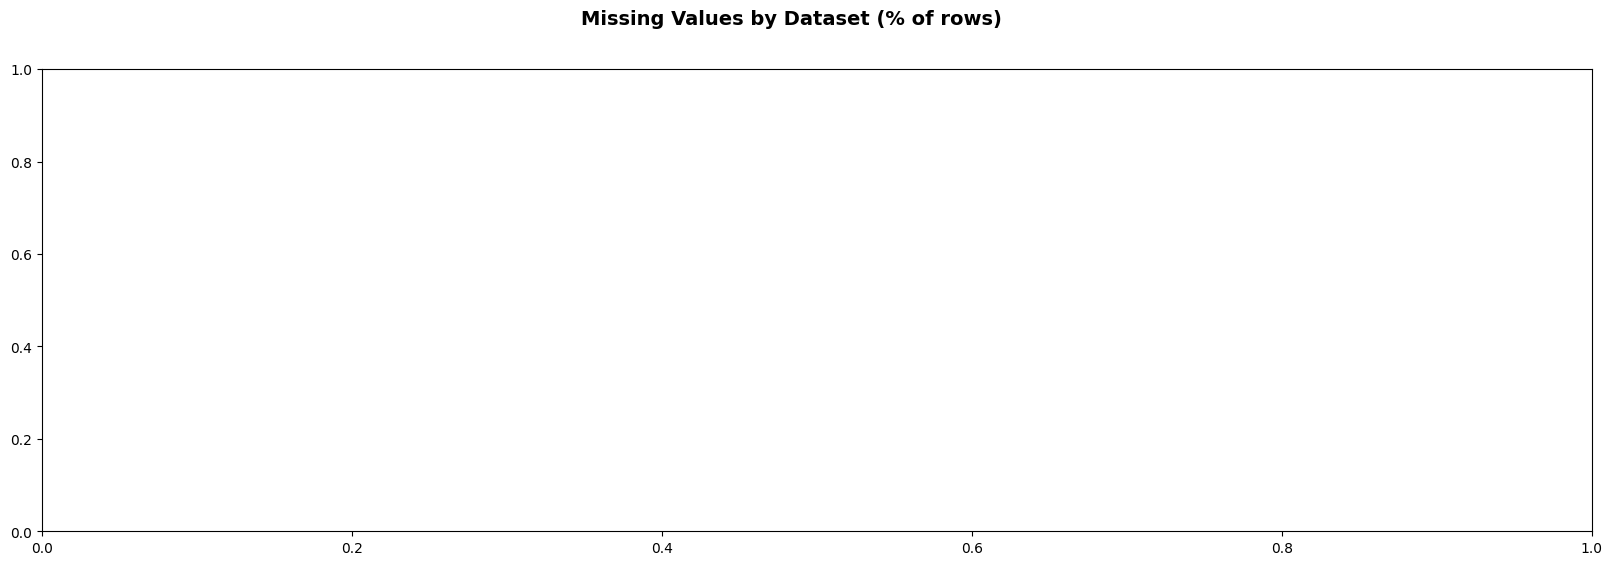

In [ ]:
fig, axes = plt.subplots(1, 1, figsize=(20, 6))
axes = [axes]

fig.suptitle("Missing Values (% of rows)", fontsize=14, fontweight="bold")

for ax, (label, df) in zip(axes, [
    ("transacciones", transacciones),
]):
    miss = (df.isnull().mean() * 100).sort_values(ascending=True)

    miss = miss[miss > 0]

    if miss.empty:
        ax.text(0.5, 0.5, "No nulls", ha="center", va="center",
                transform=ax.transAxes, fontsize=12)
        ax.set_title(label)
    else:
        miss.plot(kind="barh", ax=ax,
                  color=sns.color_palette(PALETTE, len(miss)))

        ax.set_title(label)
        ax.set_xlabel("% missing")

        for bar, val in zip(ax.patches, miss):
            ax.text(bar.get_width() + 0.5,
                    bar.get_y() + bar.get_height() / 2,
                    f"{val:.1f}%",
                    va="center",
                    fontsize=8)

plt.tight_layout()
plt.savefig(PLOTS_DIR / "01_missing_data_overview.png",
            dpi=150,
            bbox_inches="tight")
plt.close()